In [1]:
import math 
import numpy as np
import matplotlib.pyplot as plt
import scipy
# Wonder where this came from
def cross_section_circle(cross_section_parameters):
    r = cross_section_parameters[0]/2

    return {
        'area': math.pi * (r ** 2),
        'perimeter': math.pi * 2 * r,
        'second moment of area x': (math.pi / 2) * r ** 4,  # also polar moment of inertia
        'second moment of area y': (math.pi / 4) * r ** 4,
        'second moment of area z': (math.pi / 4) * r ** 4,
        'radius of gyration x': (math.sqrt(2)/2) * r,
        'radius of gyration y': r/2,
        'radius of gyration z': r/2,
        'plastic section modulus': (4/3) * r ** 3,
        'elastic section modulus': (math.pi/4) * r ** 3,
        'torsional constant': (math.pi/2) * r ** 4,
        'transverse shear deflection constant y': 6/7,
        'transverse shear deflection constant z': 6/7
    }

Y Lower X1: -0.07768196436542002
Y Lower X2: -0.1259707530250054
Y Upper X1: -0.18965323331401374
Y Upper X2: -0.30754578375245467
R Lower X1: -0.0006613464533812785
R Lower XD: 0.0008188098946625354
R Upper X1: -0.0016146153647003873
R Upper XD: 0.0019990475943909565

300
avg nom 40584510.48843332
Bending Stress Upper B :  64935216.781493306
Bending Stress Lower B :  33246830.992124565
Bending Stress Upper C :  88808458.24527761
Bending Stress Lower C :  45469930.62158213
Bending Stress Allowable:  600000000
Fail Bend?  False
110405147.40307543
Max Disp Upper:  -0.00032163494369436604
Max Disp Lower:  -0.0001317416729372123
Max Disp Allowable:  -0.0002
Fail Disp?  True


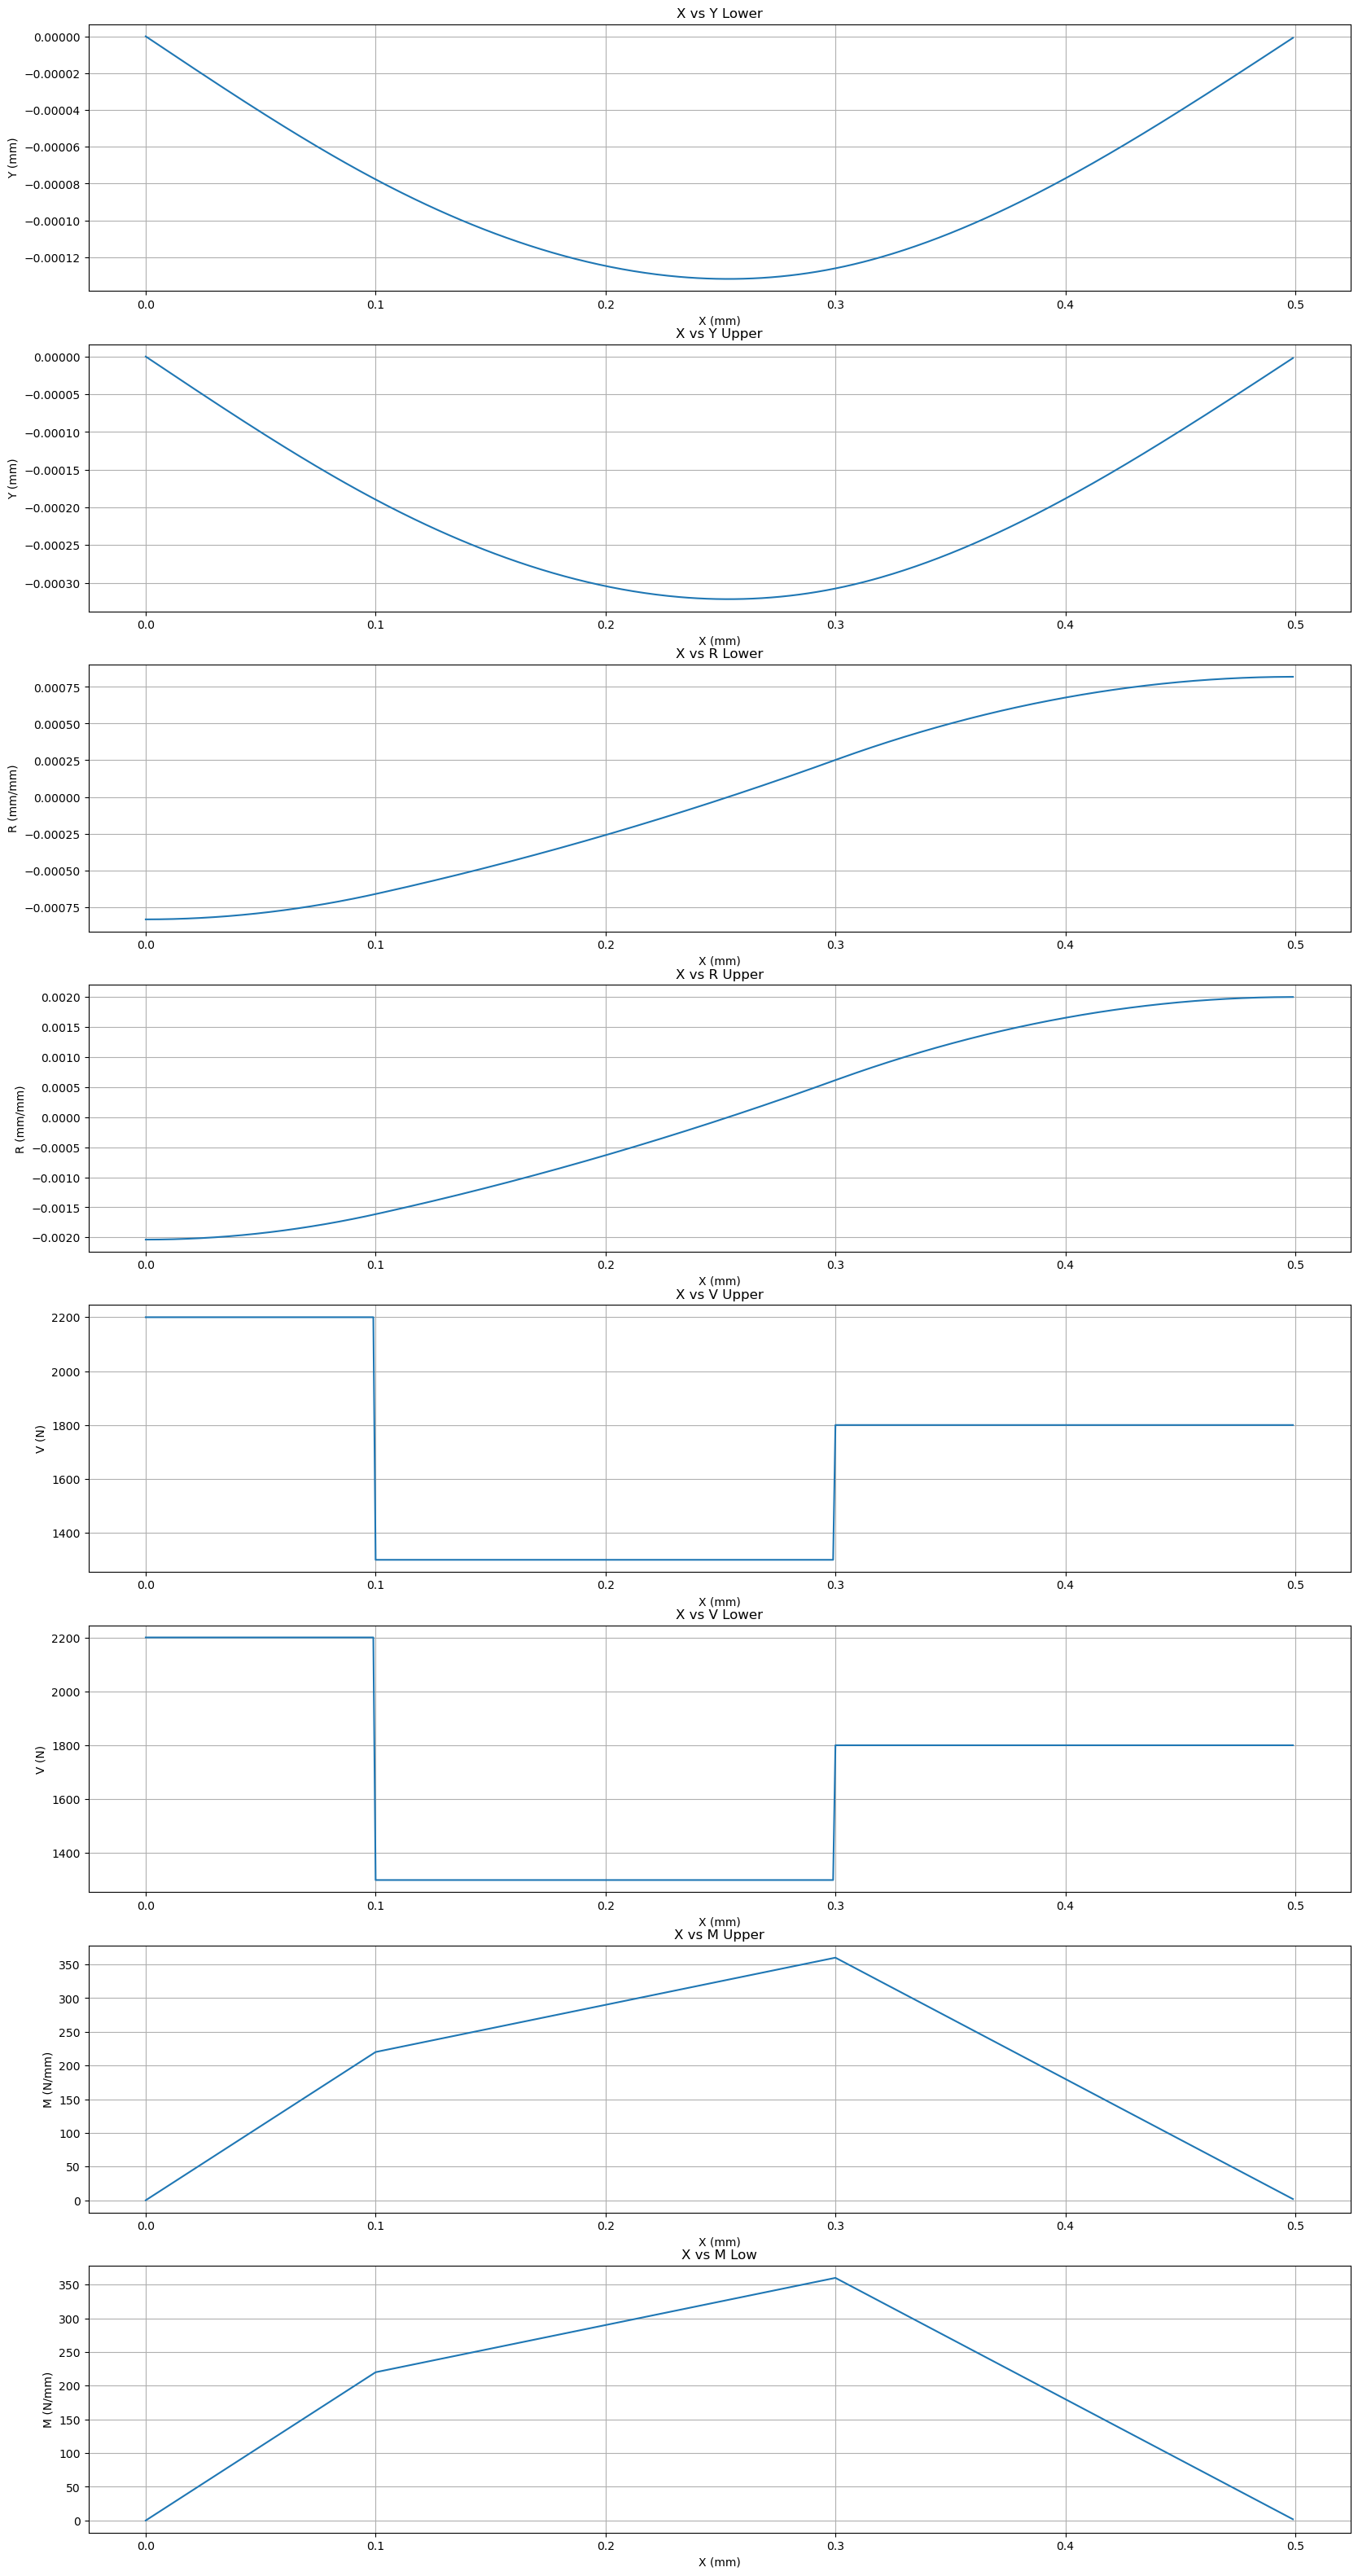

In [11]:
def shigley_case_6(EI, F, X, L, A):
    B = L - A 
    y = 0
    R = 0 
    
    if X < A:
        C1 = B ** 2  - L ** 2
        C2 = (F * B) / (6 * EI * L)
        y = (C2 * X ** 3 + C1 * C2 * X)
        R = (3 * C2 * X ** 2 + C1 * C2)
        V = F * B / L
        M = F * B * X / L
    else:
        C2 = (F * A) / (6 * EI * L)
        y = C2 * (A**2 * L - A**2 * X - 2 * L ** 2 * X + 3 * L * X ** 2 - X ** 3)
        R = C2 * (-A**2 - 2 * L ** 2 + 6 * L * X - 3 * X ** 2)
        V = F * A / L
        M = (L - X) * F * A / L

    yield y 
    yield R
    yield V
    yield M
    return



E = 207000000000

# Estimate 
Section_Properties_Est_Lower = cross_section_circle([0.05])
Section_Properties_Est_Upper = cross_section_circle([0.04])
EI_Lower = E * Section_Properties_Est_Lower['second moment of area y']
EI_Upper = E * Section_Properties_Est_Upper['second moment of area y']

Lower_Values_F1_X1, r, v, m = shigley_case_6(EI_Lower,1500,0.1,0.5,0.1)
Lower_Values_F1_X2, r, v, m  = shigley_case_6(EI_Lower,1500,0.3,0.5,0.1)
Lower_Values_F2_X1, r, v, m = shigley_case_6(EI_Lower,2500,0.1,0.5,0.3)
Lower_Values_F2_X2, r, v, m = shigley_case_6(EI_Lower,2500,0.3,0.5,0.3)
Upper_Values_F1_X1, r, v, m = shigley_case_6(EI_Upper,1500,0.1,0.5,0.1)
Upper_Values_F1_X2, r, v, m = shigley_case_6(EI_Upper,1500,0.3,0.5,0.1)
Upper_Values_F2_X1, r, v, m = shigley_case_6(EI_Upper,2500,0.1,0.5,0.3)
Upper_Values_F2_X2, r, v, m = shigley_case_6(EI_Upper,2500,0.3,0.5,0.3)

y, Lower_Values_F1_XA, v, m = shigley_case_6(EI_Lower,1500,0.1,0.5,0.1)
y, Lower_Values_F1_XD, v, m = shigley_case_6(EI_Lower,1500,0.5,0.5,0.1)
y, Lower_Values_F2_XA, v, m = shigley_case_6(EI_Lower,2500,0.1,0.5,0.3)
y, Lower_Values_F2_XD, v, m = shigley_case_6(EI_Lower,2500,0.5,0.5,0.3)
y, Upper_Values_F1_XA, v, m = shigley_case_6(EI_Upper,1500,0.1,0.5,0.1)
y, Upper_Values_F1_XD, v, m = shigley_case_6(EI_Upper,1500,0.5,0.5,0.1)
y, Upper_Values_F2_XA, v, m = shigley_case_6(EI_Upper,2500,0.1,0.5,0.3)
y, Upper_Values_F2_XD, v, m = shigley_case_6(EI_Upper,2500,0.5,0.5,0.3)

Y_Lower_X1 = Lower_Values_F1_X1 + Lower_Values_F2_X1
Y_Lower_X2 = Lower_Values_F1_X2 + Lower_Values_F2_X2

Y_Upper_X1 = Upper_Values_F1_X1 + Upper_Values_F2_X1
Y_Upper_X2 = Upper_Values_F1_X2 + Upper_Values_F2_X2

R_Lower_XA = Lower_Values_F1_XA + Lower_Values_F2_XA
R_Lower_XD = Lower_Values_F1_XD + Lower_Values_F2_XD

R_Upper_XA = Upper_Values_F1_XA + Upper_Values_F2_XA
R_Upper_XD = Upper_Values_F1_XD + Upper_Values_F2_XD

print("Y Lower X1:", Y_Lower_X1 * 1000)
print("Y Lower X2:", Y_Lower_X2* 1000)
print("Y Upper X1:", Y_Upper_X1* 1000)
print("Y Upper X2:", Y_Upper_X2* 1000)

print("R Lower X1:", R_Lower_XA)
print("R Lower XD:", R_Lower_XD)
print("R Upper X1:", R_Upper_XA)
print("R Upper XD:", R_Upper_XD)

X = np.arange(0,0.5,0.001)
Y_F1_Low = np.zeros(len(X))
Y_F2_Low = np.zeros(len(X))
R_F1_Low = np.zeros(len(X))
R_F2_Low = np.zeros(len(X))
Y_F1_Up = np.zeros(len(X))
Y_F2_Up = np.zeros(len(X))
R_F1_Up = np.zeros(len(X))
R_F2_Up = np.zeros(len(X))

V_F1_Low = np.zeros(len(X))
V_F2_Low = np.zeros(len(X))
M_F1_Low = np.zeros(len(X))
M_F2_Low = np.zeros(len(X))
V_F1_Up = np.zeros(len(X))
V_F2_Up = np.zeros(len(X))
M_F1_Up = np.zeros(len(X))
M_F2_Up = np.zeros(len(X))

for i, x in enumerate(X):
    Y_F1_Low[i], R_F1_Low[i], V_F1_Low[i], M_F1_Low[i]  = shigley_case_6(EI_Lower,1500,x,0.5,0.1)
    Y_F2_Low[i], R_F2_Low[i], V_F2_Low[i], M_F2_Low[i] = shigley_case_6(EI_Lower,2500,x,0.5,0.3)
    Y_F1_Up[i], R_F1_Up[i], V_F1_Up[i], M_F1_Up[i] = shigley_case_6(EI_Upper,1500,x,0.5,0.1)
    Y_F2_Up[i], R_F2_Up[i], V_F2_Up[i], M_F2_Up[i] = shigley_case_6(EI_Upper,2500,x,0.5,0.3)

Y_Total_Low = Y_F1_Low + Y_F2_Low
R_Total_Low = R_F1_Low + R_F2_Low
Y_Total_Up = Y_F1_Up + Y_F2_Up
R_Total_Up = R_F1_Up + R_F2_Up

M_Total_Low = M_F1_Low + M_F2_Low
V_Total_Low = V_F1_Low + V_F2_Low
M_Total_Up = M_F1_Up + M_F2_Up
V_Total_Up = V_F1_Up + V_F2_Up

fig, axs = plt.subplots(8)

fig.set_figheight(40)
fig.set_figwidth(20)

axs[0].plot(X, Y_Total_Low)
axs[0].set_title("X vs Y Lower")
axs[0].set_xlabel("X (mm)")
axs[0].set_ylabel("Y (mm)")
axs[0].grid()

axs[1].plot(X, Y_Total_Up)
axs[1].set_title("X vs Y Upper")
axs[1].set_xlabel("X (mm)")
axs[1].set_ylabel("Y (mm)")
axs[1].grid()

axs[2].plot(X, R_Total_Low)
axs[2].set_title("X vs R Lower")
axs[2].set_xlabel("X (mm)")
axs[2].set_ylabel("R (mm/mm)")
axs[2].grid()


axs[3].plot(X, R_Total_Up)
axs[3].set_title("X vs R Upper")
axs[3].set_xlabel("X (mm)")
axs[3].set_ylabel("R (mm/mm)")
axs[3].grid()

axs[4].plot(X, V_Total_Up)
axs[4].set_title("X vs V Upper")
axs[4].set_xlabel("X (mm)")
axs[4].set_ylabel("V (N)")
axs[4].grid()

axs[5].plot(X, V_Total_Low)
axs[5].set_title("X vs V Lower")
axs[5].set_xlabel("X (mm)")
axs[5].set_ylabel("V (N)")
axs[5].grid()

axs[6].plot(X, M_Total_Up)
axs[6].set_title("X vs M Upper")
axs[6].set_xlabel("X (mm)")
axs[6].set_ylabel("M (N/mm)")
axs[6].grid()

axs[7].plot(X, M_Total_Low)
axs[7].set_title("X vs M Low")
axs[7].set_xlabel("X (mm)")
axs[7].set_ylabel("M (N/mm)")
axs[7].grid()

Bending_Stress_Upper = M_Total_Up * 0.02 / Section_Properties_Est_Upper['second moment of area y']
Bending_Stress_Lower = M_Total_Low * 0.025 / Section_Properties_Est_Lower['second moment of area y']

print()

x_index_b, = np.where(np.isclose(X, 0.150))[0]
x_index_c, = np.where(np.isclose(X, 0.30))[0]
print(x_index_c)

Max_Bending_Upper_B = Bending_Stress_Upper[x_index_b] * 1.6
Max_Bending_Lower_B = Bending_Stress_Lower[x_index_b] * 1.6
Max_Bending_Upper_C = Bending_Stress_Upper[x_index_c] * 1.55
Max_Bending_Lower_C = Bending_Stress_Lower[x_index_c] * 1.55

print("est:", (Max_Bending_Upper_B)/( 1.6))

Max_Bending_Upper = np.min(Y_Total_Up) 
Max_Bending_Lower = np.min(Y_Total_Low)

print("Bending Stress Upper B : ", Max_Bending_Upper_B)
print("Bending Stress Lower B : ", Max_Bending_Lower_B)
print("Bending Stress Upper C : ", Max_Bending_Upper_C)
print("Bending Stress Lower C : ", Max_Bending_Lower_C)
print("Bending Stress Allowable: ", 600000000)
print("Fail Bend? ", 600000000 < Max_Bending_Upper_C )

print(Max_Bending_Upper_B + Max_Bending_Lower_C)

print("Max Disp Upper: ", Max_Bending_Upper)
print("Max Disp Lower: ", Max_Bending_Lower)
print("Max Disp Allowable: ", -0.0002)
print("Fail Disp? ", -0.0002 > Max_Bending_Upper)

Kuu[0,0]: 3292192751.4212537

Displacements:  [   0.          -11.16428398  -97.13977798 -120.45084791 -133.11876253 -127.09920055   -8.25273464    0.        ]
Rotations:  [-1.12088338e-03 -1.10751843e-03 -6.88871732e-04 -2.32358459e-04 -1.21404901e-05  2.57515653e-04  8.22966871e-04  8.26426761e-04]
Forces:  [ 2200.     0. -1500.     0.     0. -2500.     0.  1800.]
Moments:  [0. 0. 0. 0. 0. 0. 0. 0.]
[ 0.         -1.19366207  0.          0.        ]
-1647253.6610011233
-5.76648344535855
STRESS EST 2 PLEASE WORK
149.9999999999999
637.3033924698789
0.003078760350096033


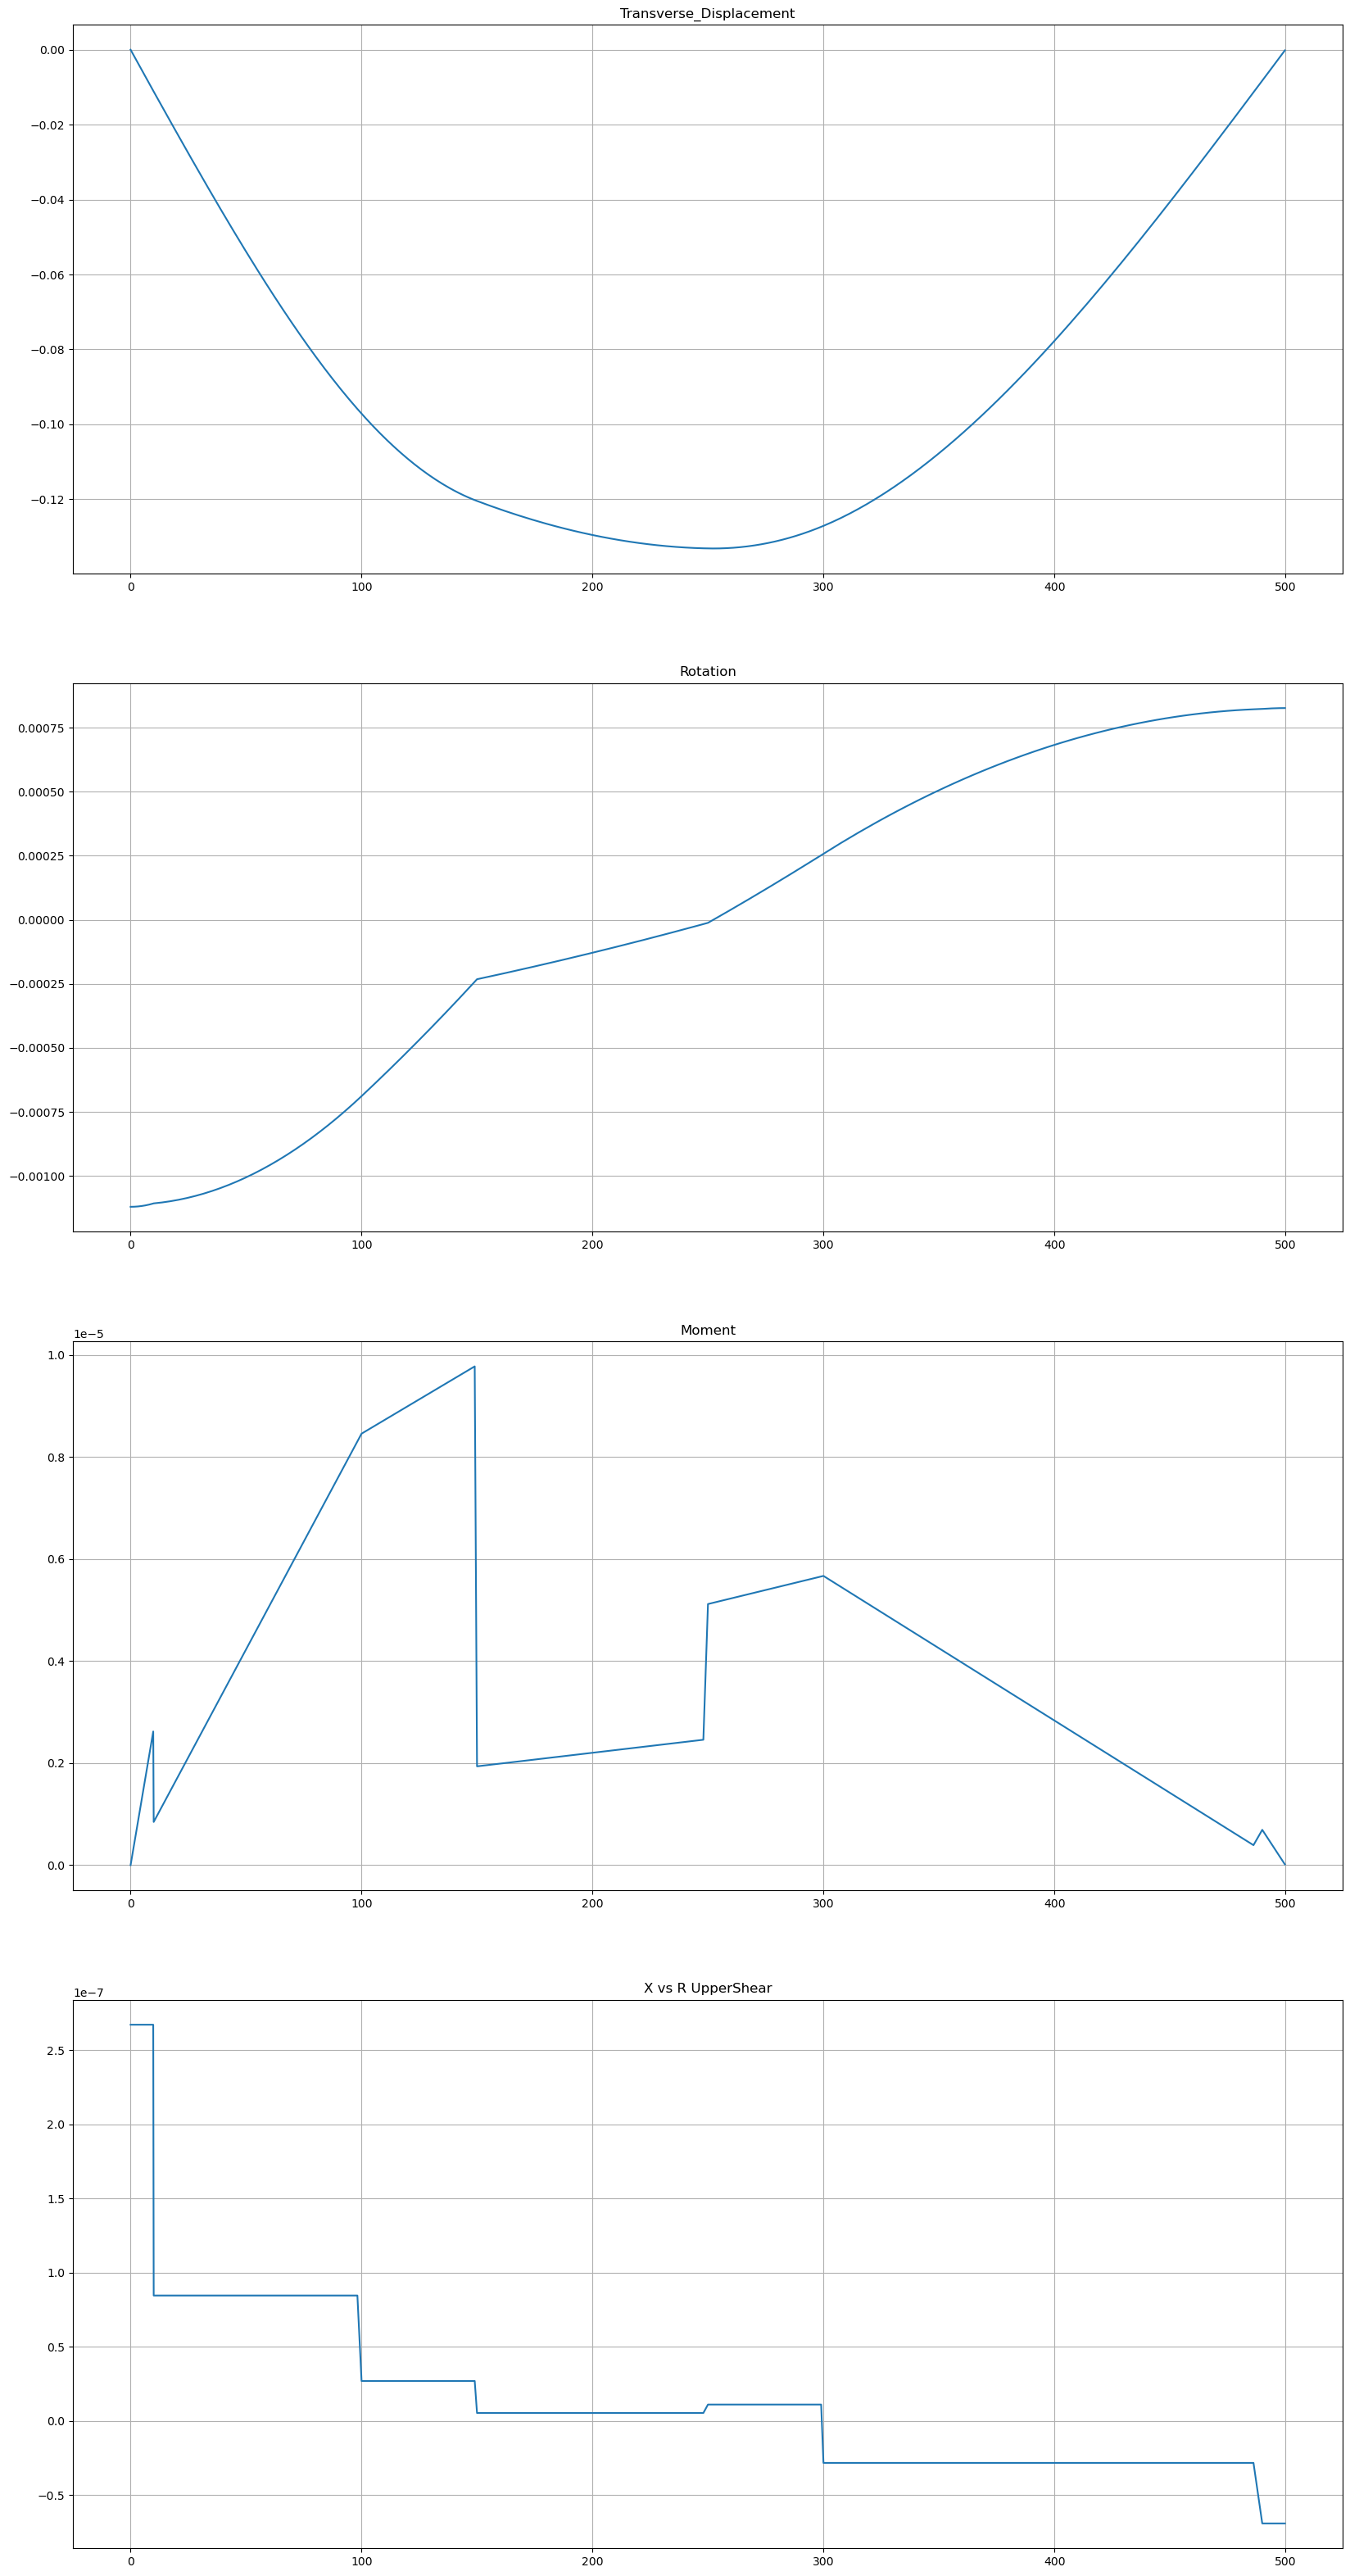

In [33]:
E = 207000


Element_Lengths = np.array([10,90,50,100,50,190,10])
Element_Diameters = np.array([30,40,40,60,50,50,40])
Element_Num = len(Element_Lengths)

EIs = np.zeros(Element_Num)
Areas = np.zeros(Element_Num)
for i in range(Element_Num):
    Section_Properties = cross_section_circle([Element_Diameters[i]])
    EIs[i] = E * Section_Properties['second moment of area y']
    Areas[i] = Section_Properties['area']

Stiffness_Matrixes = np.zeros([Element_Num,4,4])
for i in range(Element_Num):
    L = Element_Lengths[i]
    euler_bern = np.array([
        [12, 6 * L, -12, 6 * L],
        [6 * L, 4 * L ** 2, -6 * L, 2 * L ** 2],
        [-12, -6 * L, 12, -6 * L],
        [6 * L, 2 * L ** 2, -6 * L, 4 * L ** 2]])
    EIL3 = EIs[i] / (L ** 3)
    K = EIL3 * euler_bern
    Stiffness_Matrixes[i] = K

# Assembly 
Assembly_Vector = np.array([14,0,1,2,3,4,5,6,7,8,9,10,11,12,15,13])


Fu = np.array([0, 0, 0, -1500, 0, 0, 0, 0, 0, -2500, 0, 0, 0, 0]) # M0, F1, M1, F2 = 1500, M2, F3, M3, F4 , M4, F5 = 2500, M5, F6, M6, M7
Up = np.array([0, 0]) # U0 and U7

K_Global = np.zeros([len(Assembly_Vector),len(Assembly_Vector)])

for i in range(Element_Num):
    for j in range(4):
        for k in range(4):
            j_index = Assembly_Vector[j + i * 2]
            k_index = Assembly_Vector[k + i * 2]
            K_Global[j_index, k_index] += Stiffness_Matrixes[i,j,k]

Kuu = K_Global[:14,:14]
Kp = K_Global[14:]
print("Kuu[0,0]:", Kuu[0,0])
np.set_printoptions(linewidth=400)
# print("K: ", np.round(K_Global))

Uu = scipy.linalg.solve(Kuu, Fu)
U_ = np.concatenate([Uu,Up])
Fp = Kp @ U_
F_ = np.concatenate([Fu,Fp])

# Rearrange Vector
U = np.zeros(len(Assembly_Vector))
F = np.zeros(len(Assembly_Vector))
for i in range(len(Assembly_Vector)):
    U[i] = U_[Assembly_Vector[i]]
    F[i] = F_[Assembly_Vector[i]]
    
Displacements = U[::2]
Rotations = U[1::2]
Forces = F[::2]
Moments = F[1::2]

np.set_printoptions(linewidth=400)
print("\nDisplacements: ", Displacements * 1000)
print("Rotations: ", Rotations)
print("Forces: ", Forces)
print("Moments: ", Moments)

Stress = np.zeros([Element_Num,4])
for i in range(Element_Num):
    A = Areas[i]
    Section_Properties = cross_section_circle([Element_Diameters[i]])
    Z = Section_Properties['second moment of area y'] / (Element_Diameters[i]/2)
    C = np.array([[0, -1/Z, 0, 0],[1/A, 0, 0, 0],[0,0,0,1/Z],[0,0,-1/A,0]])
    Stress[i] = C @ np.transpose(np.array([F[i*2],F[1+i*2],F[i*2+2],F[i*2+3]]))

print(Stress[2])

segments_per_element = 50
X = np.zeros(segments_per_element * Element_Num)
Transverse_Displacement = np.zeros(segments_per_element * Element_Num)
Rotation = np.zeros(segments_per_element * Element_Num)
Moment = np.zeros(segments_per_element * Element_Num)
Shear = np.zeros(segments_per_element * Element_Num)
x = 0
for i in range(Element_Num):
    U_local = U[2*i:2*i+4]
    for j in range(segments_per_element):
        X[i * segments_per_element + j] = x
        x_l = Element_Lengths[i] * j / segments_per_element
        l =  Element_Lengths[i]
        N1 = 1 - (3 * x_l ** 2 / l ** 2) + (2 * x_l ** 3 / l ** 3)
        N2 = x_l - (2 * x_l ** 2 / l) + (x_l ** 3 / l ** 2)
        N3 = (3 * x_l ** 2 / l ** 2) - (2 * x_l ** 3 / l ** 3)
        N4 = (x_l ** 3 / l ** 2) - (x_l ** 2 / l)
        
        N1_dx = - 6 * x_l / l ** 2 + 6 * x_l ** 2 / l ** 3
        N2_dx = 1 - 4 * x_l / l + 3 * x_l ** 2 / l ** 2
        N3_dx = 6 * x_l / l ** 2 - 6 * x_l ** 2 / l ** 3
        N4_dx = 3 * x_l ** 2 / l ** 2 - 2 * x_l / l

        N1_dx2 = - 6 / l ** 2 + 12 * x_l / l ** 3
        N2_dx2 = - 4 / l + 6 * x_l / l ** 2
        N3_dx2 = 6 / l ** 2 - 12 * x_l / l ** 3
        N4_dx2 = 6 * x_l / l ** 2 - 2 / l

        N1_dx3 = 12 / l ** 3
        N2_dx3 = 6 / l ** 2
        N3_dx3 = - 12 / l ** 3
        N4_dx3 = 6 / l ** 2
        
        
        Transverse_Displacement[i * segments_per_element + j] = N1 * U_local[0] + N2 * U_local[1] + N3 * U_local[2] + N4 * U_local[3]
        Rotation[i * segments_per_element + j] = N1_dx * U_local[0] + N2_dx * U_local[1] + N3_dx * U_local[2] + N4_dx * U_local[3]
        Moment[i * segments_per_element + j] = N1_dx2 * U_local[0] + N2_dx2 * U_local[1] + N3_dx2 * U_local[2] + N4_dx2 * U_local[3]
        Shear[i * segments_per_element + j] = N1_dx3 * U_local[0] + N2_dx3 * U_local[1] + N3_dx3 * U_local[2] + N4_dx3 * U_local[3]
        
        x += Element_Lengths[i] / segments_per_element
        
    
fig, axs = plt.subplots(4)

fig.set_figheight(40)
fig.set_figwidth(20)

axs[0].plot(X, Transverse_Displacement)
axs[0].set_title("Transverse_Displacement")
axs[0].grid()

axs[1].plot(X, Rotation)
axs[1].set_title("Rotation")
axs[1].grid()

axs[2].plot(X, Moment)
axs[2].set_title("Moment")
axs[2].grid()


axs[3].plot(X, Shear)
axs[3].set_title("X vs R UpperShear")
axs[3].grid()

print(-1193662.07318922 * 1.38)
print(-1193662.07318922 / E)
print("STRESS EST 2 PLEASE WORK")
print(X[150])
print(Moment[149] * (20 / Section_Properties_Est_Lower['second moment of area y']))
print(Moment[149] * (20 / Section_Properties_Est_Lower['second moment of area y']) / E )